# Proyek Klasifikasi Gambar: **DETEKSI MIKROKONTROLER**
- **Nama:** [HOLLANDA ARIEF KUSUMA]
- **Email:** [hollandacocobear@gmail.com]
- **ID Dicoding:** [Hollanda]

## 1. Import Semua Packages/Library yang Digunakan

In [2]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import library yang dibutuhkan

!pip install --upgrade tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback


from sklearn.model_selection import train_test_split
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

!pip install tensorflowjs
import tensorflowjs as tfjs

import numpy as np

# Ekspor requirements.txt
!pip freeze > /content/drive/MyDrive/requirements.txt
!mv /content/drive/MyDrive/requirements.txt /content/drive/MyDrive/proyek\ akhir/


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.1
    Uninstalling packaging-24.1:
      Successfully uninstalled packaging-24.1


## 2. Data Preparation

### A. Data Loading

In [4]:
# Tentukan direktori dataset di Google Drive
base_dir = '/content/drive/MyDrive/proyek akhir'  #lokasi folder dataset

# Tentukan direktori untuk masing-masing kelas
classes = ['Arduino Mega','Arduino Nano','Arduino Pro Mini','Arduino Uno','ESP32 CAM','ESP32 DEV KIT V1','RASP PI','Sparkfun ESP32 Thing','Wemos D1','Wemos D1 Mini']

# Buat daftar semua gambar beserta labelnya dan hitung jumlah gambar per folder
filepaths = []
labels = []
folder_image_count = {}

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    num_images = len(os.listdir(class_dir))
    folder_image_count[class_name] = num_images

    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        filepaths.append(fpath)
        labels.append(class_name)

# Tampilkan jumlah gambar di setiap folder
print("Jumlah gambar di setiap folder:")
for class_name, count in folder_image_count.items():
    print(f"{class_name}: {count} gambar")

# Tampilkan label yang digunakan dalam pengklasifikasian
print("\nLabel yang akan digunakan dalam pengklasifikasian:")
print(classes)

Jumlah gambar di setiap folder:
Arduino Mega: 100 gambar
Arduino Nano: 100 gambar
Arduino Pro Mini: 100 gambar
Arduino Uno: 100 gambar
ESP32 CAM: 100 gambar
ESP32 DEV KIT V1: 100 gambar
RASP PI: 100 gambar
Sparkfun ESP32 Thing: 100 gambar
Wemos D1: 100 gambar
Wemos D1 Mini: 100 gambar

Label yang akan digunakan dalam pengklasifikasian:
['Arduino Mega', 'Arduino Nano', 'Arduino Pro Mini', 'Arduino Uno', 'ESP32 CAM', 'ESP32 DEV KIT V1', 'RASP PI', 'Sparkfun ESP32 Thing', 'Wemos D1', 'Wemos D1 Mini']


### B. Data Preprocessing

In [5]:
def get_unique_images_by_size(base_dir, classes, num_images_per_class=5):
    selected_images = []
    selected_labels = []

    for class_name in classes:
        class_dir = os.path.join(base_dir, class_name)
        size_dict = {}

        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            with Image.open(fpath) as img:
                size = img.size

                # Jika ukuran gambar unik, tambahkan ke daftar
                if size not in size_dict:
                    size_dict[size] = fpath
                    selected_labels.append(class_name)

                # Hentikan jika sudah mendapatkan num_images_per_class gambar dengan ukuran unik
                if len(size_dict) >= num_images_per_class:
                    break

        # Tambahkan semua gambar unik yang ditemukan untuk kelas ini ke daftar hasil akhir
        selected_images.extend(size_dict.values())

    return selected_images, selected_labels

# Dapatkan 2 gambar dengan ukuran berbeda dari setiap kelas
unique_images, unique_labels = get_unique_images_by_size(base_dir, classes, num_images_per_class=2)

# Tampilkan hasil beserta ukuran gambar
print("Label, Filepath, dan Ukuran Dimensi Gambar:")
for img, label in zip(unique_images, unique_labels):
    with Image.open(img) as image:
        size = image.size
    print(f"Label: {label}, Filepath: {img}, Ukuran: {size} pixel")


Label, Filepath, dan Ukuran Dimensi Gambar:
Label: Arduino Mega, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Mega/2.png, Ukuran: (600, 450) pixel
Label: Arduino Mega, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Mega/3.jpg, Ukuran: (600, 600) pixel
Label: Arduino Nano, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Nano/01.jpg, Ukuran: (700, 556) pixel
Label: Arduino Nano, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Nano/02.png, Ukuran: (1500, 1500) pixel
Label: Arduino Pro Mini, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Pro Mini/02.jpg, Ukuran: (600, 600) pixel
Label: Arduino Pro Mini, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Pro Mini/04.jpg, Ukuran: (1024, 552) pixel
Label: Arduino Uno, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Uno/01.png, Ukuran: (277, 205) pixel
Label: Arduino Uno, Filepath: /content/drive/MyDrive/proyek akhir/Arduino Uno/03.png, Ukuran: (600, 600) pixel
Label: ESP32 CAM, Filepath: /content/dr

In [6]:
# Mengonversi label ke dalam bentuk numerik
label_to_index = {label: idx for idx, label in enumerate(classes)}
numeric_labels = np.array([label_to_index[label] for label in labels])

# Membuat ImageDataGenerator untuk preprocessing gambar
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Tampilkan informasi dasar tentang data yang telah diproses
print("Data preprocessing selesai:")
print(f"Total gambar: {len(filepaths)}")
print(f"Jumlah kelas: {len(classes)}")

# Loop untuk menampilkan informasi label numerik
for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    numeric_label = label_to_index[class_name]
    num_images = len(os.listdir(class_dir))

    # Menampilkan informasi
    print(f"Class: {class_name}; Label numerik: {[numeric_label] * 1}")


Data preprocessing selesai:
Total gambar: 1000
Jumlah kelas: 10
Class: Arduino Mega; Label numerik: [0]
Class: Arduino Nano; Label numerik: [1]
Class: Arduino Pro Mini; Label numerik: [2]
Class: Arduino Uno; Label numerik: [3]
Class: ESP32 CAM; Label numerik: [4]
Class: ESP32 DEV KIT V1; Label numerik: [5]
Class: RASP PI; Label numerik: [6]
Class: Sparkfun ESP32 Thing; Label numerik: [7]
Class: Wemos D1; Label numerik: [8]
Class: Wemos D1 Mini; Label numerik: [9]


#### C. Split Dataset

In [7]:
panjang= 100
lebar = 100
batshSize = 64

# Membagi data menjadi data latih dan data uji
# Pisahkan data menjadi training (80%) dan testing (20%)
print('Split Dataset 80% training dan 20% testing')
train_files, test_files, train_labels, test_labels = train_test_split(filepaths,
                                                                      numeric_labels, test_size=0.2, random_state=42,stratify=labels)

# Konversi label numerik ke dalam bentuk string
train_labels_str = [str(label) for label in train_labels]
test_labels_str = [str(label) for label in test_labels]

# Membuat generator data untuk training dan validation
train_generator = datagen.flow_from_dataframe(
    dataframe=pd.DataFrame({'filename': train_files, 'class': train_labels_str}),
    x_col='filename',
    y_col='class',
    target_size=(panjang, lebar),  # Sesuaikan ukuran gambar dengan kebutuhan model
    batch_size=batshSize,
    class_mode='sparse',
    color_mode='rgb'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=pd.DataFrame({'filename': test_files, 'class': test_labels_str}),
    x_col='filename',
    y_col='class',
    target_size=(panjang, lebar),  # Sesuaikan ukuran gambar dengan kebutuhan model
    batch_size=batshSize,
    class_mode='sparse',
    color_mode='rgb'
)

# Tampilkan informasi tentang generator
print("Training data:")
print(f"Total images: {train_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

print("\nValidation data:")
print(f"Total images: {val_generator.samples}")
print(f"Classes: {val_generator.class_indices}")


Split Dataset 80% training dan 20% testing
Found 800 validated image filenames belonging to 10 classes.
Found 200 validated image filenames belonging to 10 classes.
Training data:
Total images: 800
Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}

Validation data:
Total images: 200
Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


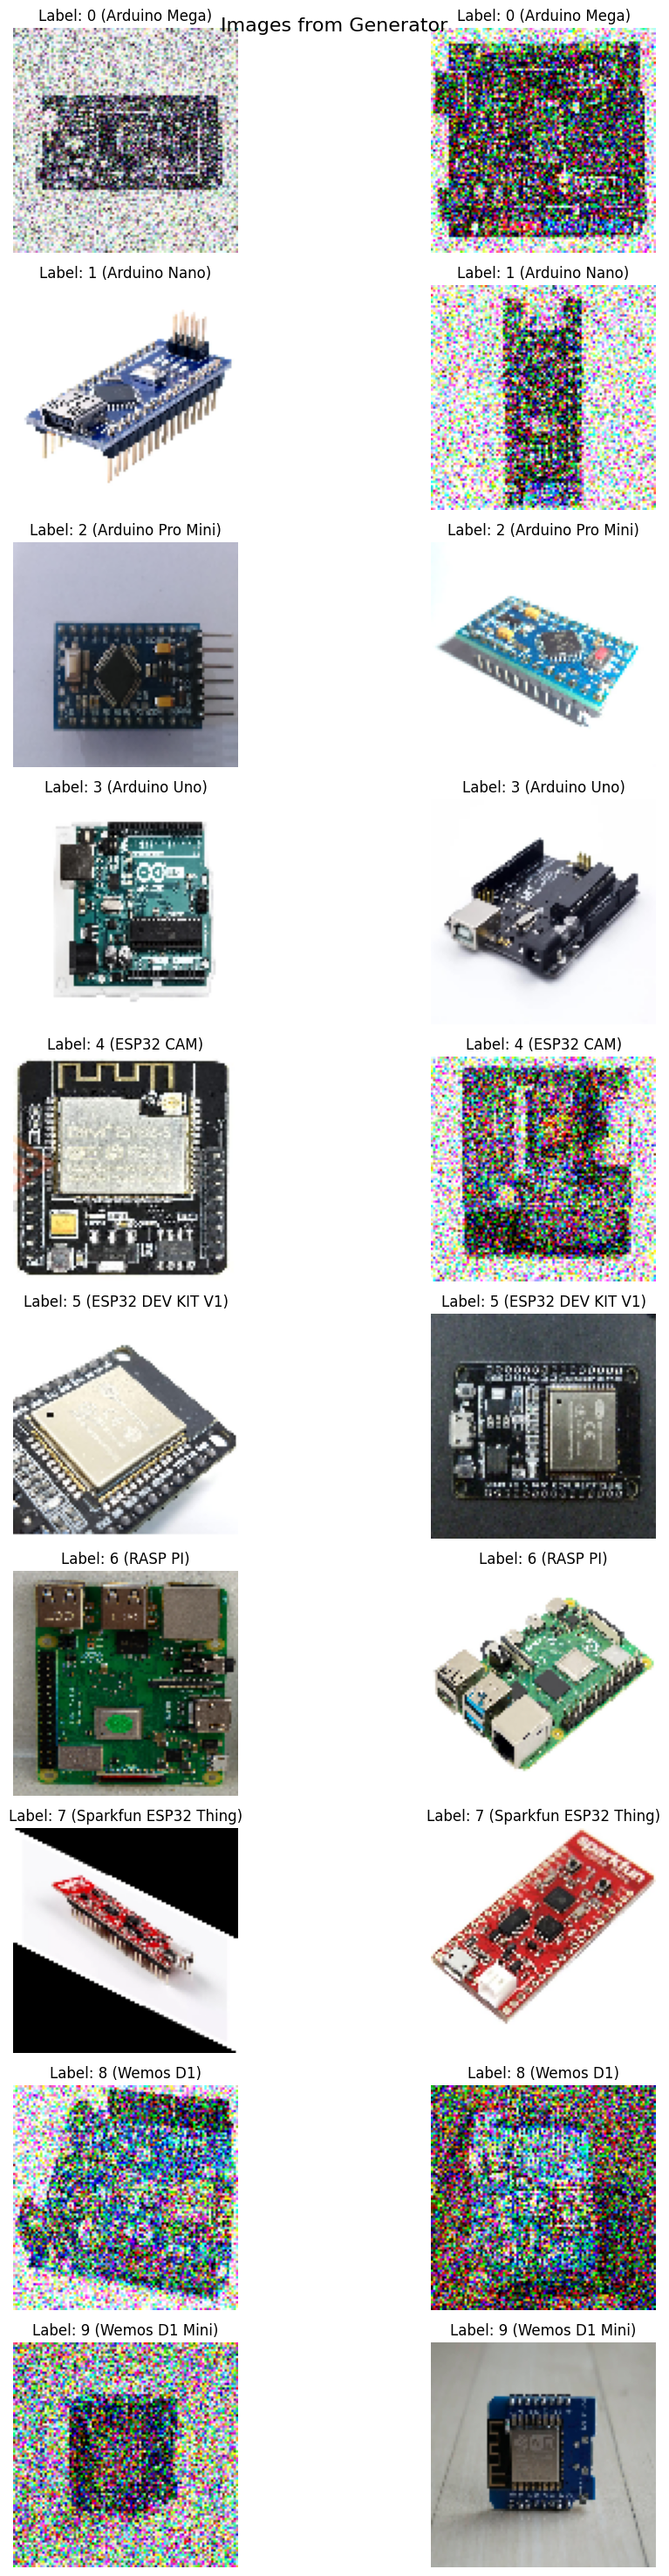

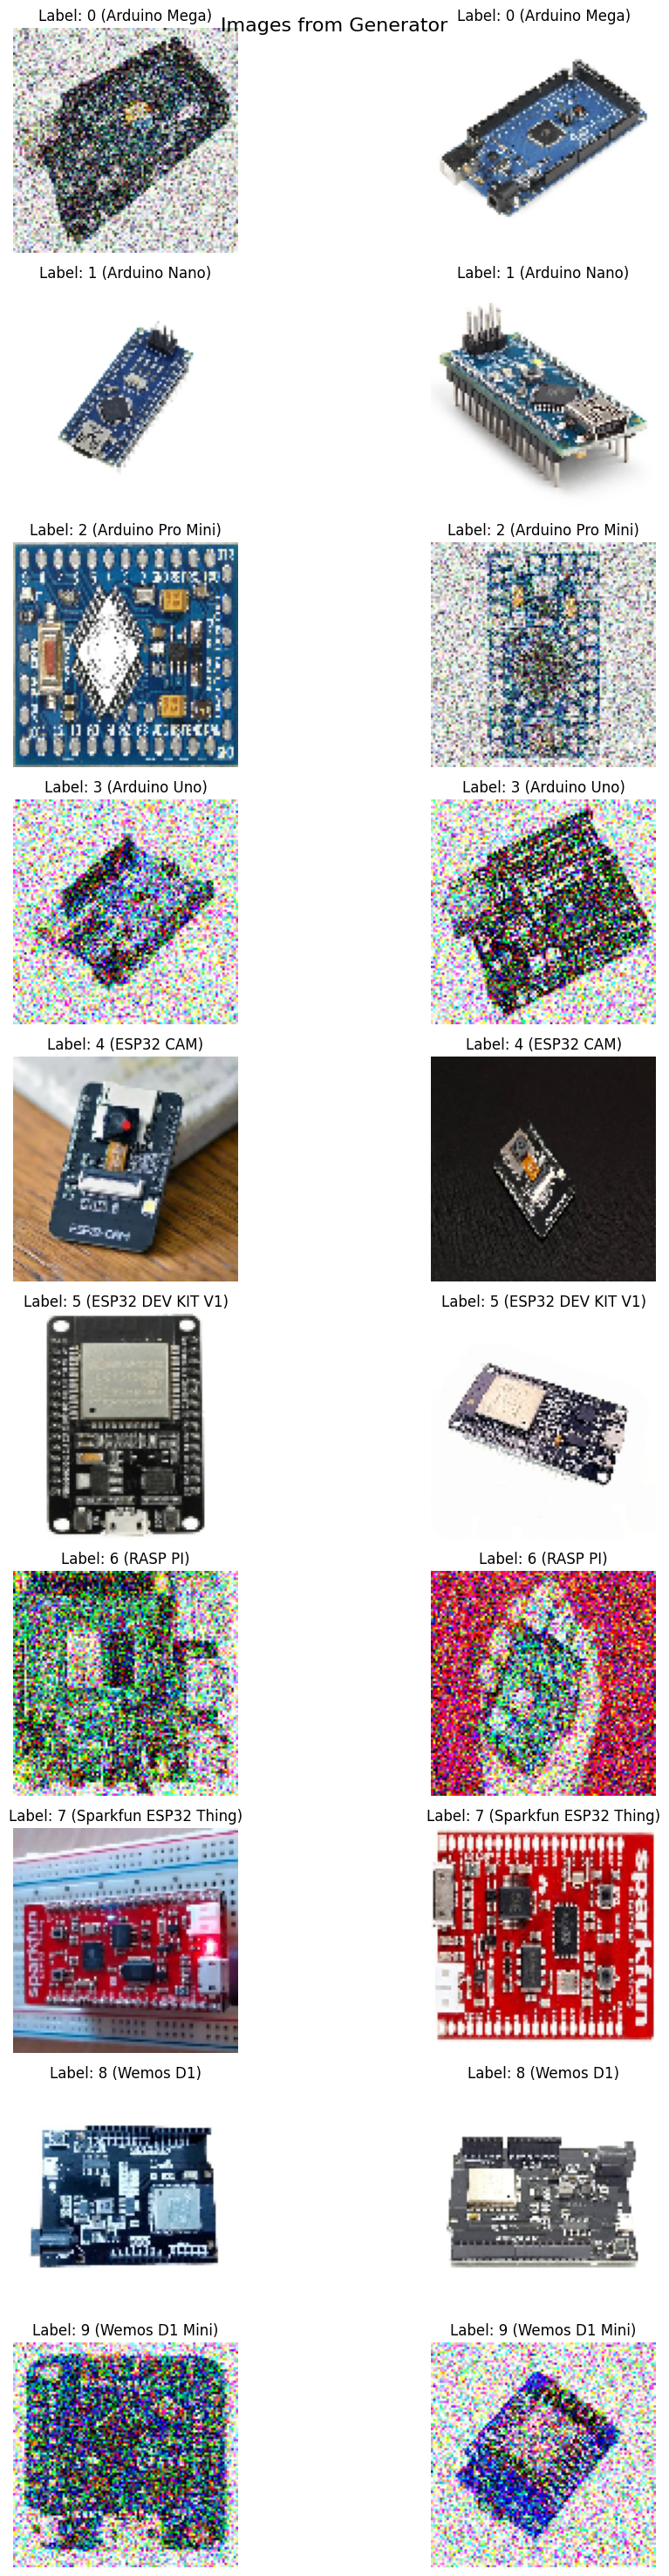

In [8]:
def plot_images_per_class(generator, classes, title, num_images_per_class=2):
    # Menyimpan gambar per kelas
    images_per_class = {class_name: [] for class_name in classes}

    # Mengumpulkan gambar untuk setiap kelas
    while any(len(images) < num_images_per_class for images in images_per_class.values()):
        batch = next(generator)
        images, labels = batch

        # Jika label dalam format sparse (integer), pastikan untuk mengubahnya menjadi integer
        if labels.dtype == 'float32':
            labels = labels.astype(int)

        for i in range(images.shape[0]):
            label_index = int(labels[i])  # Konversi label ke integer
            label_name = classes[label_index]  # Mendapatkan nama kelas dari variabel classes
            if len(images_per_class[label_name]) < num_images_per_class:
                images_per_class[label_name].append(images[i])

    # Menampilkan gambar
    num_classes = len(classes)
    plt.figure(figsize=(12, num_classes * 3))  # Ukuran figure sesuai dengan jumlah kelas dan gambar

    for idx, (class_name, class_images) in enumerate(images_per_class.items()):
        for i, image in enumerate(class_images):
            plt.subplot(num_classes, num_images_per_class, idx * num_images_per_class + i + 1)
            plt.imshow(image)
            plt.title(f"Label: {idx} ({class_name})")
            plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot gambar dari train_generator
plot_images_per_class(train_generator, classes, "Train Generator Samples", num_images_per_class=2)

# Plot gambar dari val_generator
plot_images_per_class(val_generator, classes, "Validation Generator Samples", num_images_per_class=2)


## 3. Modelling

In [9]:
nilaiDropout = 0.4
nilaiLearningRate=1e-3

# Membangun model CNN
model = Sequential([
    tf.keras.layers.Input(shape=(panjang, lebar, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    #Conv2D(256, (3, 3), activation='relu'),  # Lapisan tambahan
    #MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(nilaiDropout), # Penurunan nilai dropout
    Dense(len(classes), activation='softmax')
])

# Tampilkan ringkasan model
print("Model Summary:")
model.summary()

# Compile model
model.compile(optimizer=Adam(learning_rate=nilaiLearningRate),  # Mencoba learning rate yang lebih tinggi
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Tampilkan konfigurasi compile model
print("\nModel Compilation Configuration:")
print(f"Optimizer: {model.optimizer.get_config()}")
print(f"Loss function: {model.loss}")
print(f"Metrics: {model.metrics_names}")

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,638,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,733,066 (6.61 MB)

 Trainable params: 1,733,066 (6.61 MB)

 Non-trainable params: 0 (0.00 B)


Model Compilation Configuration:
Optimizer: {'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}
Loss function: sparse_categorical_crossentropy
Metrics: ['loss', 'compile_metrics']


## 4. Evaluasi dan Visualisasi

In [10]:
# Evaluasi Model
print('LATIH MODEL')
# Jumlah epoch yang diinginkan
jumlahEpoch=250;
print('Jumlah Epoch = ', jumlahEpoch)

# Callback untuk menghentikan pelatihan ketika akurasi validasi mencapai 96%
class StopTrainingCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.96:
            print("\nReached 96% validation accuracy, stopping training.")
            self.model.stop_training = True

stop_training_callback = StopTrainingCallback()

# Callback EarlyStopping untuk menghentikan pelatihan jika tidak ada perbaikan
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# Mengimplementasikan Callback
callbacks = [
    stop_training_callback,
    ModelCheckpoint(filepath='/content/drive/MyDrive/checkpoints/model-{epoch:02d}.keras',
                    save_best_only=True,
                    monitor='val_accuracy',
                    mode='max'),
    early_stopping_callback
]

# Melatih model
print("Training Model")
history = model.fit(
    train_generator,
    epochs=jumlahEpoch,
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluasi dan Visualisasi
print("Evaluasi Model:")
loss, accuracy = model.evaluate(val_generator)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

LATIH MODEL
Jumlah Epoch =  250
Training Model
Epoch 1/250


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 330s 16s/step - accuracy: 0.1487 - loss: 2.4166 - val_accuracy: 0.2850 - val_loss: 2.2497
Epoch 2/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.2142 - loss: 2.2024 - val_accuracy: 0.3450 - val_loss: 1.9505
Epoch 3/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.3254 - loss: 1.9284 - val_accuracy: 0.3850 - val_loss: 1.7471
Epoch 4/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3805 - loss: 1.7145 - val_accuracy: 0.4800 - val_loss: 1.5484
Epoch 5/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.4275 - loss: 1.5985 - val_accuracy: 0.5450 - val_loss: 1.3951
Epoch 6/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.5599 - loss: 1.3492 - val_accuracy: 0.5900 - val_loss: 1.1695
Epoch 7/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.5655 - loss: 1.2410 - val_accuracy: 0.6400 - val_loss: 1.0846
Epoch 8/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6502 - loss: 1.0461 - val_accuracy: 0.6750 - val_loss: 

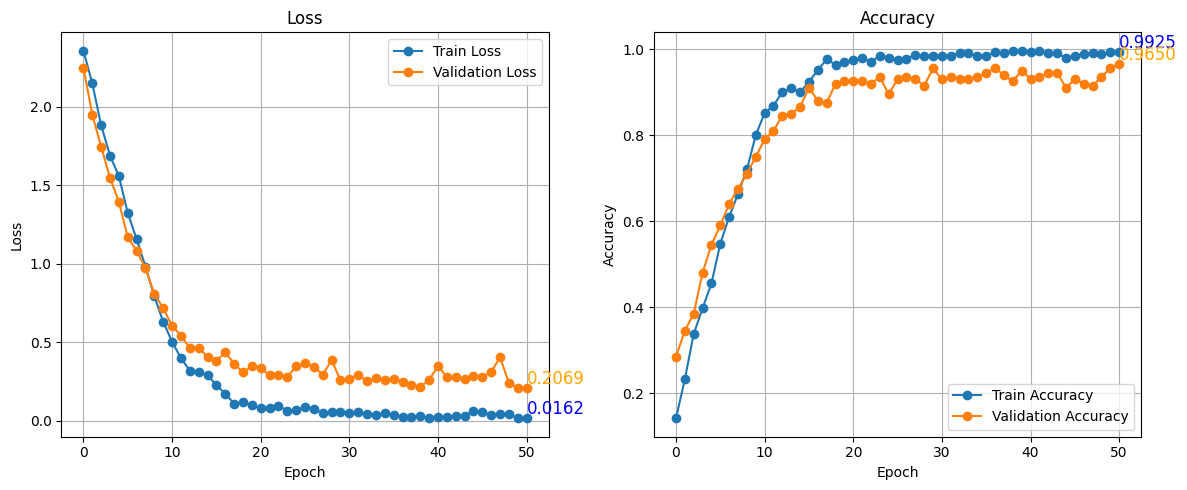

In [11]:
nilaiXTick=10
# Plot akurasi dan loss
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(history.history['loss']) + 1, nilaiXTick))  # Set xticks every 10 epochs
plt.grid(True)
plt.legend()
# Menambahkan teks nilai loss di akhir plot
plt.text(len(history.history['loss']) - 1, history.history['loss'][-1],
         f'{history.history["loss"][-1]:.4f}',
         horizontalalignment='left', verticalalignment='bottom',
         fontsize=12, color='blue')
plt.text(len(history.history['loss']) - 1, history.history['val_loss'][-1],
         f'{history.history["val_loss"][-1]:.4f}',
         horizontalalignment='left', verticalalignment='bottom',
         fontsize=12, color='orange')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(0, len(history.history['accuracy']) + 1, nilaiXTick))  # Set xticks every 5 epochs
plt.grid(True)
plt.legend()
# Menambahkan teks nilai accuracy di akhir plot
plt.text(len(history.history['accuracy']) - 1, history.history['accuracy'][-1],
         f'{history.history["accuracy"][-1]:.4f}',
         horizontalalignment='left', verticalalignment='bottom',
         fontsize=12, color='blue')
plt.text(len(history.history['accuracy']) - 1, history.history['val_accuracy'][-1],
         f'{history.history["val_accuracy"][-1]:.4f}',
         horizontalalignment='left', verticalalignment='bottom',
         fontsize=12, color='orange')

plt.tight_layout()
plt.show()

## 5. Konversi Model

In [66]:
# 1. SavedModel
saved_model_dir = '/content/drive/MyDrive/proyek akhir/saved_model/'
os.makedirs(saved_model_dir, exist_ok=True)  # Membuat direktori jika belum ada
tf.saved_model.save(model, saved_model_dir)

# 2. TensorFlow Lite
tflite_dir = '/content/drive/MyDrive/proyek akhir/tflite/'
os.makedirs(tflite_dir, exist_ok=True)  # Membuat direktori jika belum ada
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(os.path.join(tflite_dir, 'model.tflite'), 'wb') as f:
    f.write(tflite_model)

# Simpan label untuk TensorFlow Lite
with open(os.path.join(tflite_dir, 'label.txt'), 'w') as f:
    for label in classes:
        f.write(f"{label}\n")

# 3. TensorFlow.js
tfjs_target_dir = '/content/drive/MyDrive/proyek akhir/tfjs_model/'
os.makedirs(tfjs_target_dir, exist_ok=True)  # Membuat direktori jika belum ada
tfjs.converters.save_keras_model(model, tfjs_target_dir)

print("Model dan TensorFlow Lite, TensorFlow.js, dan SavedModel telah disimpan.")

Saved artifact at '/tmp/tmpbbzhrlrs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139930100383808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930089413744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930063832688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930063842192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100405296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100412864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100406176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100411984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100044672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930100047312: TensorSpec(shape=(), dtype=tf.resource, name=None)


failed to lookup keras version from the file,
    this is likely a weight only file
Model dan TensorFlow Lite, TensorFlow.js, dan SavedModel telah disimpan.


## 6. Inference

In [60]:
# Load TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/proyek akhir/tflite/model.tflite')
#model_arrow_classifier.tflite')
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:")
print(input_details)
print("\nOutput Details:")
print(output_details)

# Tentukan ukuran gambar yang diharapkan oleh model
input_height, input_width = input_details[0]['shape'][1:3]

# Tentukan jumlah gambar per kelas untuk diuji
num_images_per_class = 4  # Ubah jika perlu

# Mengumpulkan gambar, label, prediksi, dan hasil perbandingan
images_to_plot = []
labels_to_plot = []
predictions_to_plot = []
comparison_results = []

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    class_filepaths = [os.path.join(class_dir, fname) for fname in os.listdir(class_dir)][:num_images_per_class]

    for fpath in class_filepaths:
        img = Image.open(fpath).resize((input_width, input_height)).convert('RGB')  # Pastikan ukuran gambar sesuai dengan input model
        input_data = np.expand_dims(np.array(img) / 255.0, axis=0).astype(np.float32)

        # Lakukan inferensi
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()

        # Ambil hasil prediksi
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predicted_class = np.argmax(output_data)

        # Simpan gambar, label, prediksi, dan hasil perbandingan
        images_to_plot.append(img)
        labels_to_plot.append(class_name)
        predicted_label = classes[predicted_class]
        predictions_to_plot.append(predicted_label)
        comparison_results.append("Sesuai" if class_name == predicted_label else "Tidak Sesuai")

# Membuat tabel perbandingan
comparison_df = pd.DataFrame({
    'Gambar Asli': labels_to_plot,
    'Hasil Prediksi': predictions_to_plot,
    'Sesuai': comparison_results
})

# Tampilkan tabel perbandingan
print(comparison_df)

# Hitung persentase prediksi yang benar
accuracy = comparison_df['Sesuai'].value_counts(normalize=True).get('Sesuai', 0) * 100
print(f"Persentase prediksi yang benar: {accuracy:.2f}%")


Input Details:
[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([  1, 100, 100,   3], dtype=int32), 'shape_signature': array([ -1, 100, 100,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output Details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 21, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
             Gambar Asli        Hasil Prediksi  Sesuai
0           Arduino Mega          Arduino Mega  Sesuai
1           Arduino Mega          Arduino Mega  Sesuai
2           Arduino Mega          Arduino Mega  Sesuai
3  

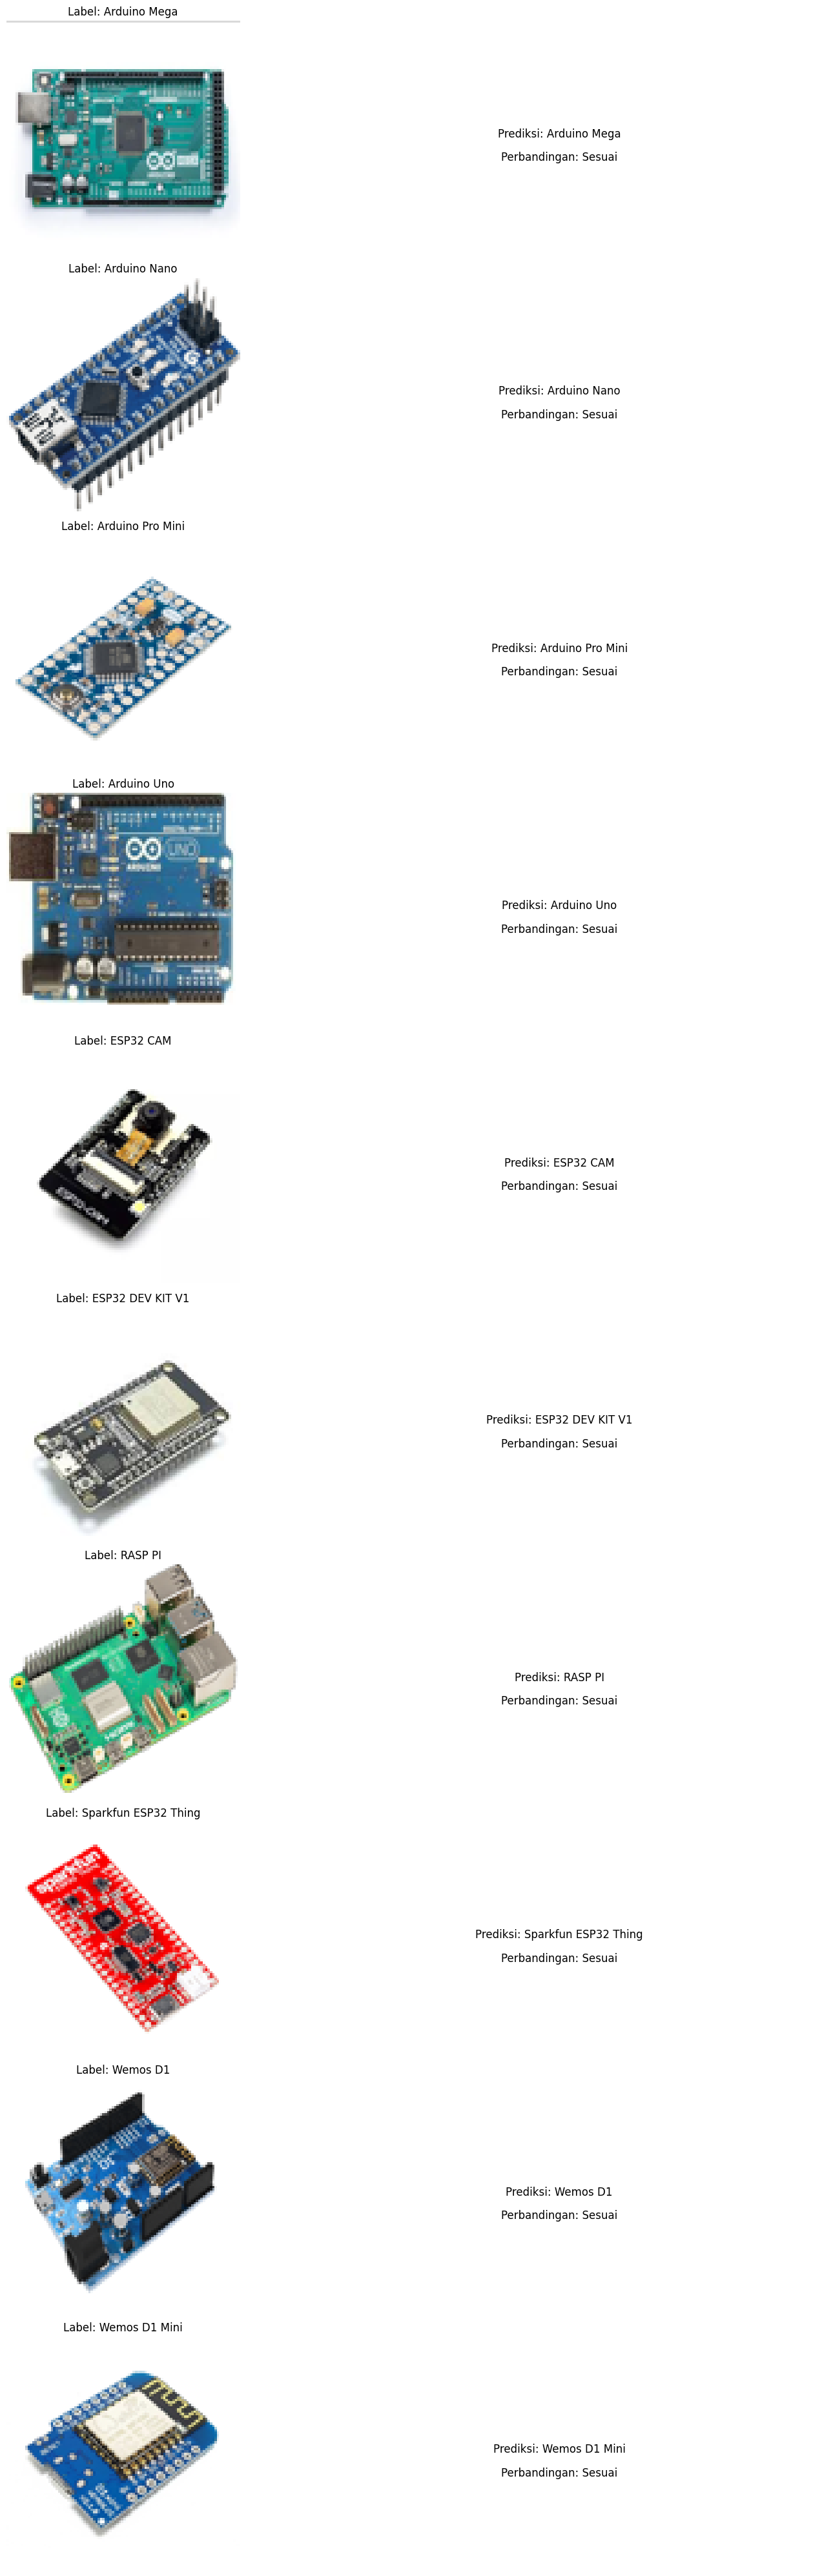

In [55]:

# Menyiapkan figure dan axes untuk plot
fig, axes = plt.subplots(nrows=len(classes), ncols=2, figsize=(15, len(classes) * 4))

# Menampilkan gambar asli dan hasil prediksi
for i, (img, true_label, pred_label) in enumerate(zip(images_to_plot, labels_to_plot, predictions_to_plot)):
    ax_img = axes[i, 0]
    ax_pred = axes[i, 1]

    # Menampilkan gambar asli
    ax_img.imshow(img)
    ax_img.set_title(f"Label: {true_label}", fontsize=12)
    ax_img.axis('off')

    # Menampilkan hasil prediksi
    ax_pred.text(0.5, 0.5, f'Prediksi: {pred_label}', fontsize=12, ha='center')
    ax_pred.text(0.5, 0.4, f'Perbandingan: {"Sesuai" if true_label == pred_label else "Tidak Sesuai"}', fontsize=12, ha='center')
    ax_pred.axis('off')

plt.tight_layout()
plt.show()
